In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

Total messages processed: 1860
Total messages dropped: 0
      index  Sending_Timestamp  Receiving_Timestamp  latency  grupo  \
0         0      1779787970198        1779787970239       41     10   
1         1      1779787970699        1779787970739       40     10   
2         2      1779787971199        1779787971240       41     10   
3         3      1779787971699        1779787971741       42     10   
4         4      1779787972199        1779787972241       42     10   
...     ...                ...                  ...      ...    ...   
1855   1855      1779789047912        1779789047959       47   1000   
1856   1856      1779789048412        1779789048459       47   1000   
1857   1857      1779789048912        1779789048960       48   1000   
1858   1858      1779789049412        1779789049460       48   1000   
1859   1859      1779789049912        1779789049961       49   1000   

      arrived_timestamp  leaving_timestamp  latency_s_s  
0      7242523211077261   724252

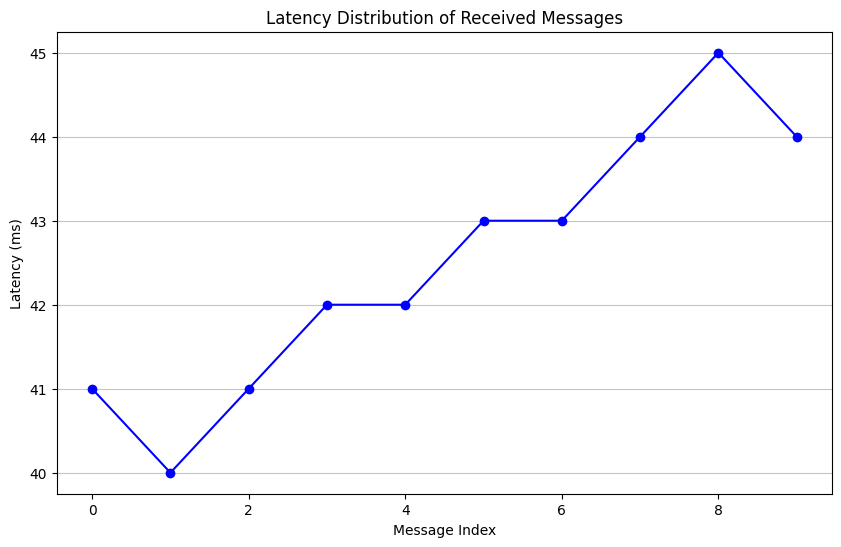

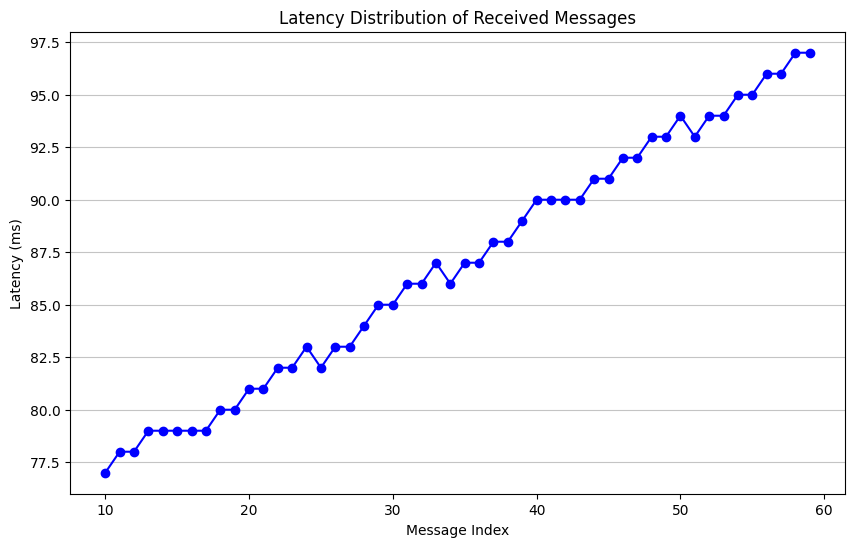

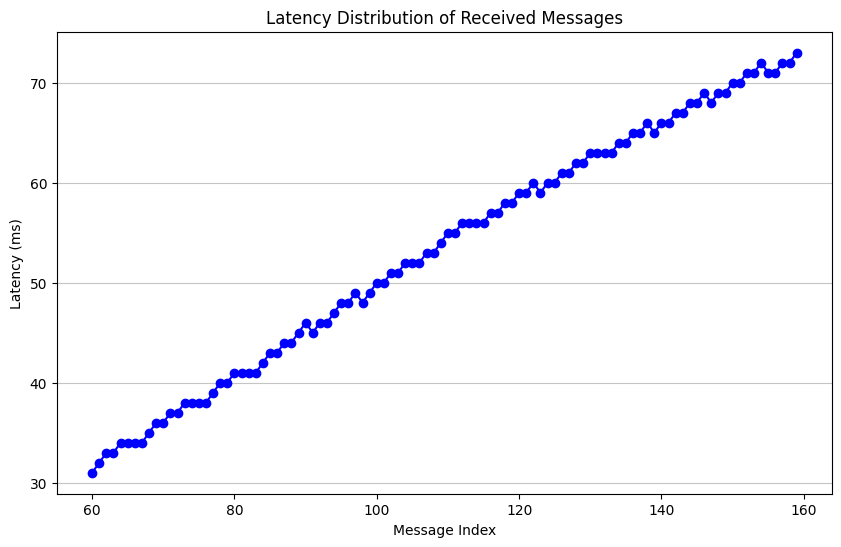

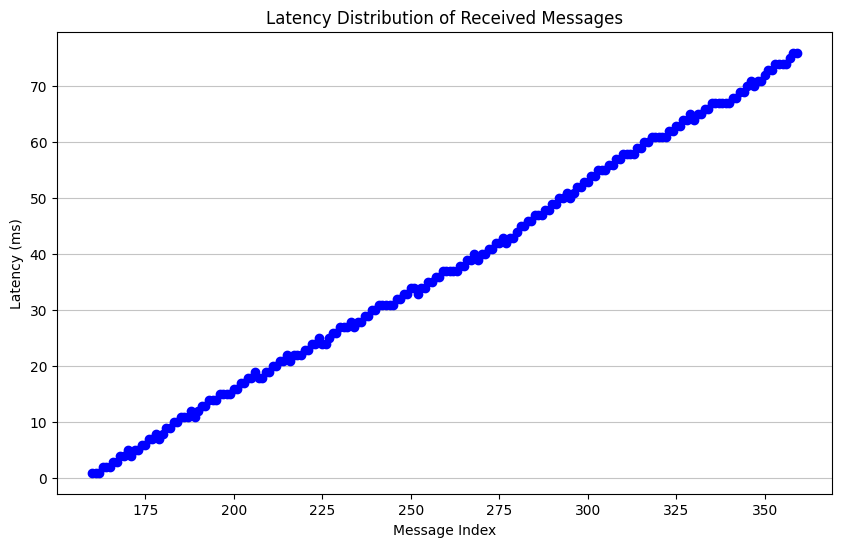

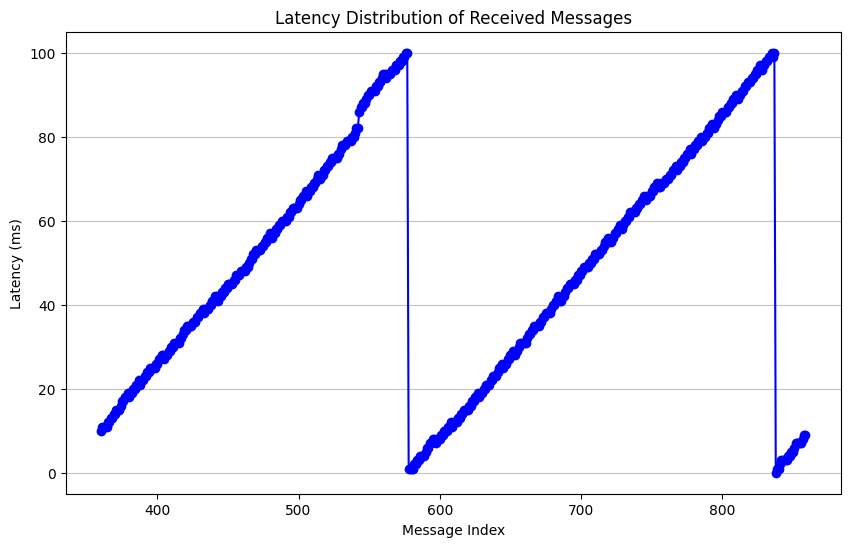

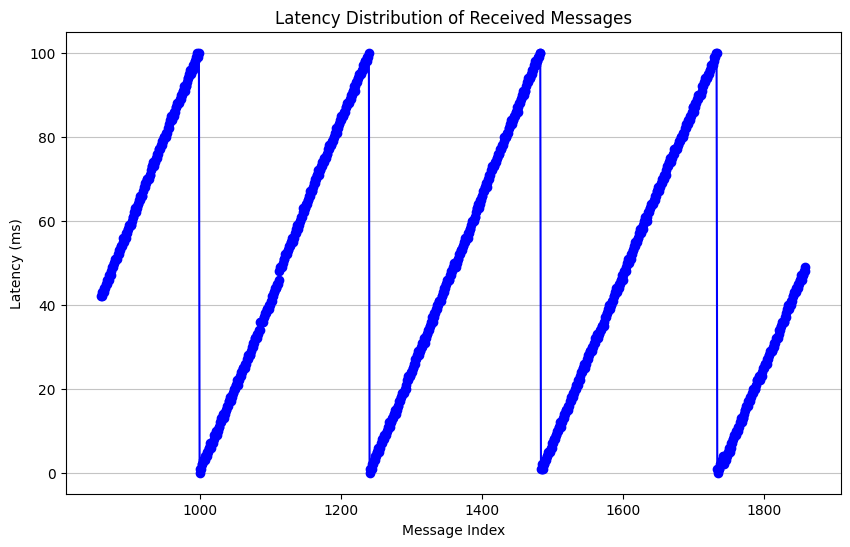

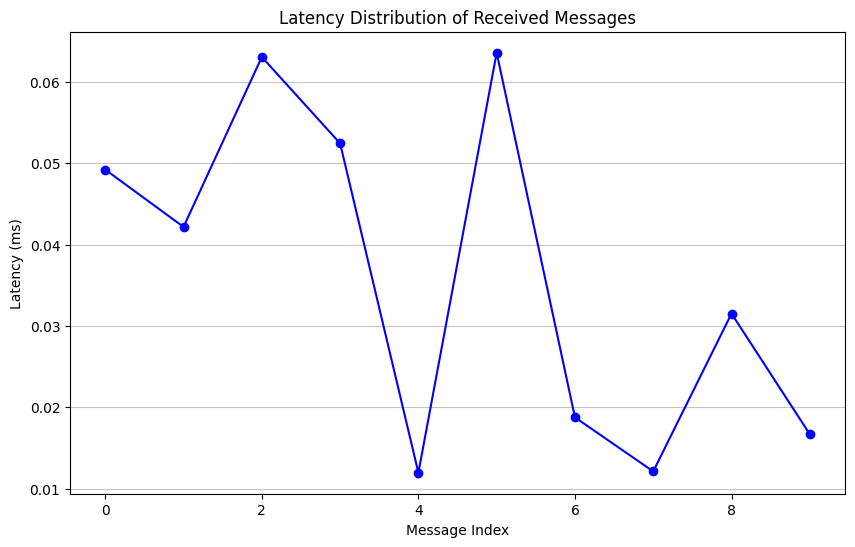

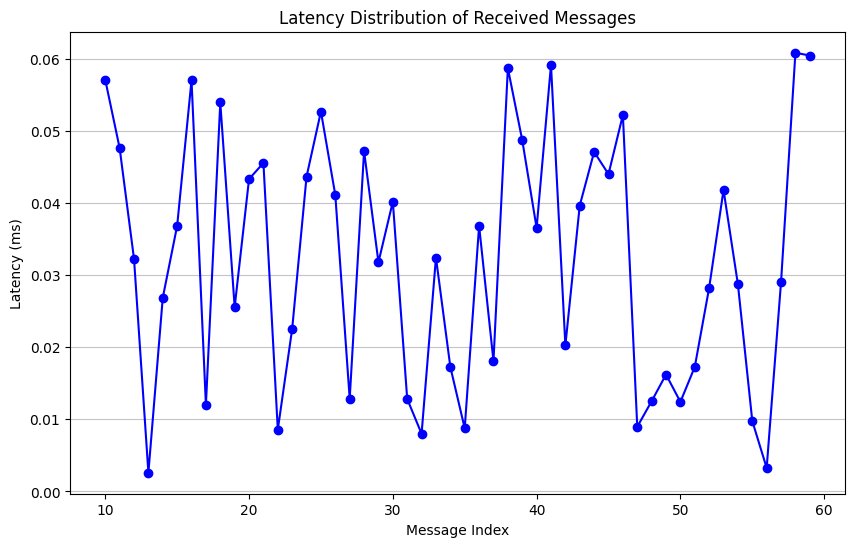

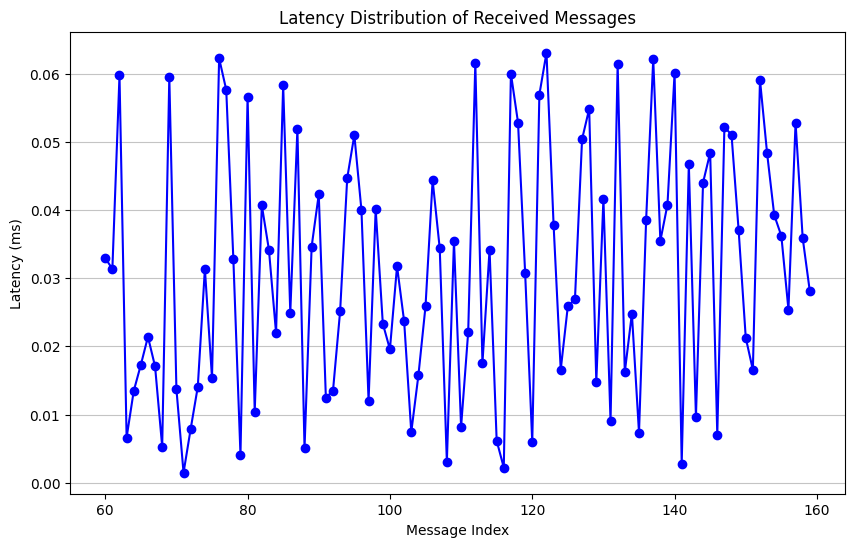

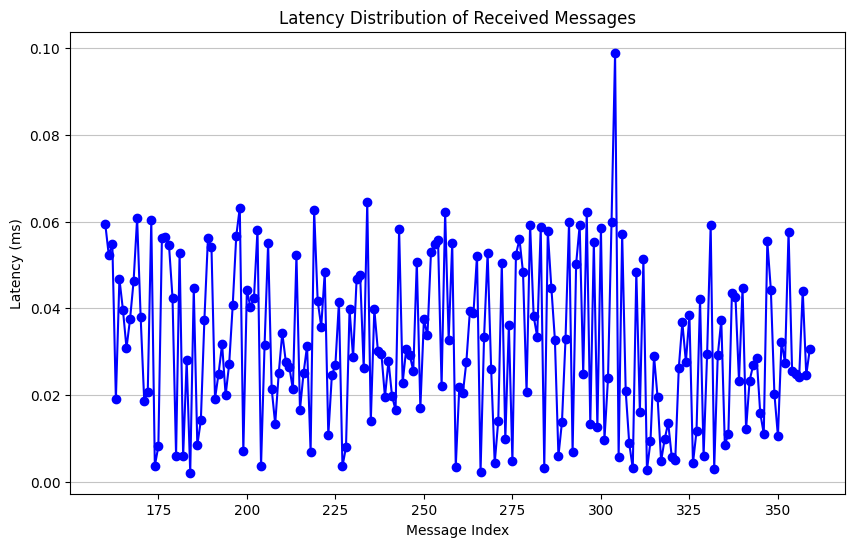

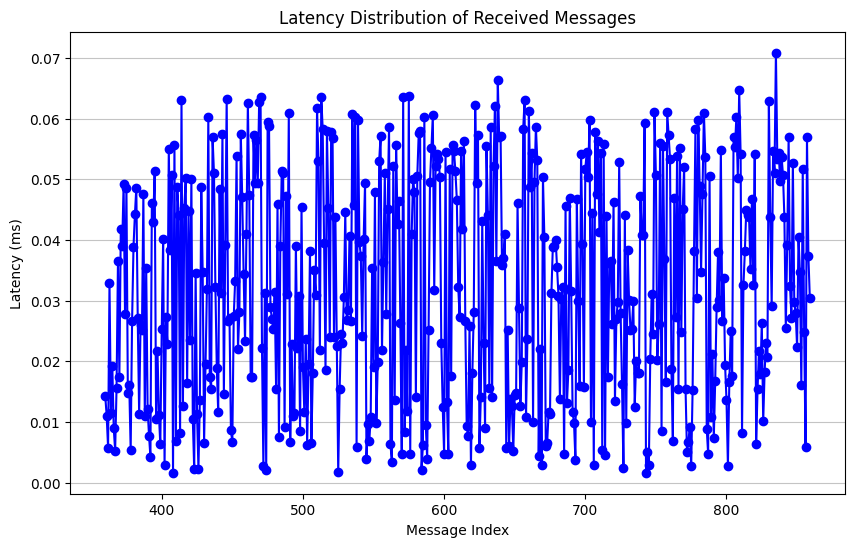

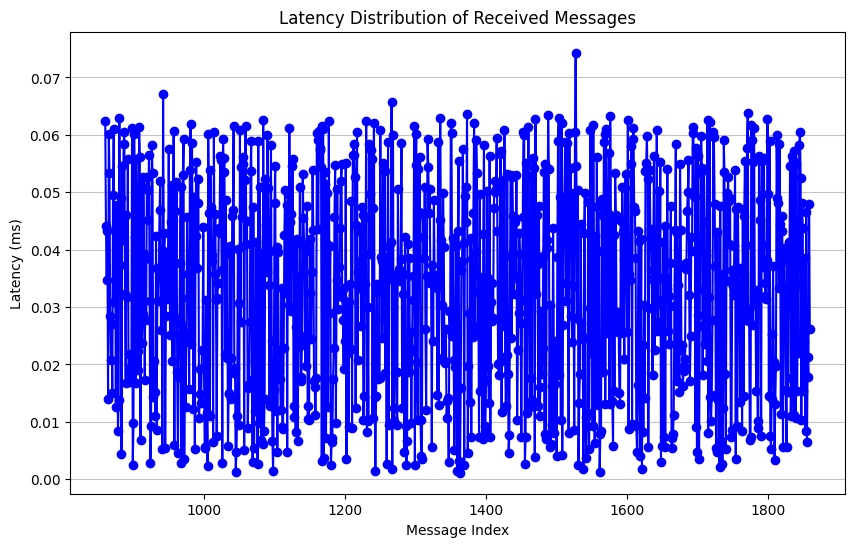

In [10]:
df = pd.read_csv('mensajes_recibidos2.csv')


df['latency'] = df['Receiving_Timestamp'] - df['Sending_Timestamp']

df.reset_index(inplace=True)



pruebas = [10, 50, 100, 200, 500, 1000]
lista = []
contador = 0
for prueba in pruebas:
    for i in range(0, prueba):
        lista.append(prueba)
        contador += 1



df['grupo'] = lista   

for prueba in pruebas:
    df2 = df[df['grupo'] == prueba]
    plt.figure(figsize=(10, 6))
    plt.plot(df2['index'], df2['latency'], marker='o', linestyle='-', color='blue')
    # plt.hist(df[df2]['latency'], bins=30, color='blue', edgecolor='black')

    plt.title('Latency Distribution of Received Messages')
    plt.xlabel('Message Index')
    plt.ylabel('Latency (ms)')
    plt.grid(axis='y', alpha=0.75)
    plt.savefig(f'latency_distribution_{prueba}.png')



print("Total messages processed:", contador)
print("Total messages dropped:", sum(pruebas) - contador)




fdf = pd.read_csv('resultados_experimento.csv')
ldf = pd.read_csv('resultados_experimento2.csv')


df['arrived_timestamp'] = fdf['timestamp_ns']
df['leaving_timestamp'] = ldf['timestamp_ns']

df['latency_s_s'] = (df['leaving_timestamp'] - df['arrived_timestamp'])/1000000



print(df)


for prueba in pruebas:
    df2 = df[df['grupo'] == prueba]
    plt.figure(figsize=(10, 6))
    plt.plot(df2['index'], df2['latency_s_s'], marker='o', linestyle='-', color='blue')
    # plt.hist(df[df2]['latency'], bins=30, color='blue', edgecolor='black')

    plt.title('Latency Distribution of Received Messages')
    plt.xlabel('Message Index')
    plt.ylabel('Latency (ms)')
    plt.grid(axis='y', alpha=0.75)
    plt.savefig(f'latency_distribution_s_s_{prueba}.png')
